# Round 006 — ตระกูล F: ML baseline

**ทำอะไร:** ให้ gradient boosting และ tree ตื้น ๆ เรียนรู้จากสัญญาณ 19 ตัวแบบ walk-forward (เทรนเฉพาะข้อมูลที่รู้ผลแล้ว)

**อุปมา:** ใช้ "ผู้ช่วยอัจฉริยะ" มาลองดูว่าถ้าผสมทุกอย่างอย่างฉลาดที่สุดจะชนะไหม — เป็นเพดานเทียบ ไม่ใช่ผลที่จะนำไปใช้

**อ่านผลอย่างไร:** สเปกใน rounds/round_006/HYPOTHESIS.md; กฎของ tree ใน rounds/round_006/tree_rules.txt

In [1]:
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
from IPython.display import Image, Markdown, display
from lib import report
report.banner()
r = pd.read_csv("../rounds/round_006/results.csv")
cols = [c for c in ["trial_id","dec_sharpe","dec_sharpe_ew","dec_sharpe_spy","dec_cagr","dec_cagr_ew","dec_maxdd","dec_maxdd_ew",
        "S1_10","S1_25","S2_share","DSR","S6_avg_n","S6_min_n","info_sharpe","info_sharpe_ew"] if c in r.columns]
pd.set_option("display.width", 250); pd.set_option("display.max_rows", 200)
display(r[cols].round(3))
ok = lambda c: r[c].astype(str).str.lower().eq("true")
print("ผู้เข้ารอบ (S1+S2+S3+S6):", list(r[ok("S1") & ok("S2") & ok("S3") & ok("S6")].trial_id))


> ⚠️ **คำเตือน survivorship bias (แสดงในทุก notebook)**
> รายชื่อสมาชิกมาจาก fja05680/sp500 (point-in-time) แต่ **ราคามาจาก yfinance ซึ่งเก็บเฉพาะหุ้นที่ยังซื้อขายอยู่**
> หุ้นที่ถูกซื้อกิจการ/ล้มละลาย/เปลี่ยนชื่อจำนวนหนึ่งจึงไม่มีราคา และหลุดออกจาก backtest
> ผลตอบแทนที่คำนวณได้จึงมีแนวโน้ม **สูงกว่าความจริง** (หุ้นที่ "ตาย" ไปมักเป็นหุ้นที่ผลตอบแทนแย่)
> สัดส่วนที่ขาดหายวัดไว้ใน `v0_data_audit.ipynb`

> ⚠️ **ข้อจำกัดของ held-out**: held-out = rebalance มิ.ย. 2023, 2024, 2025 (3 รอบเต็ม) + มิ.ย. 2026 ที่ถือได้แค่ ~3 เดือน
> (รอบ 2026 เป็นข้อมูลประกอบ ไม่นับตัดสิน) — มีแค่ 2–3 รอบ rebalance ที่ใช้ตัดสิน ผลช่วงนี้จึงมีความไม่แน่นอนสูงมาก
> ใช้เป็นการตรวจทิศทางเท่านั้น ไม่ใช่หลักฐานทางสถิติ


,trial_id,dec_sharpe,dec_sharpe_ew,dec_sharpe_spy,dec_cagr,dec_cagr_ew,dec_maxdd,dec_maxdd_ew,S1_10,S1_25,S2_share,DSR,S6_avg_n,S6_min_n,info_sharpe,info_sharpe_ew
0,r006_F_GBM,0.636,0.64,0.681,0.129,0.125,-0.373,-0.376,False,False,0.297,0.013,99.083,57,0.976,1.137
1,r006_F_TREE2,0.526,0.64,0.681,0.103,0.125,-0.394,-0.376,False,False,0.108,0.000,99.083,57,1.133,1.137


ผู้เข้ารอบ (S1+S2+S3+S6): []


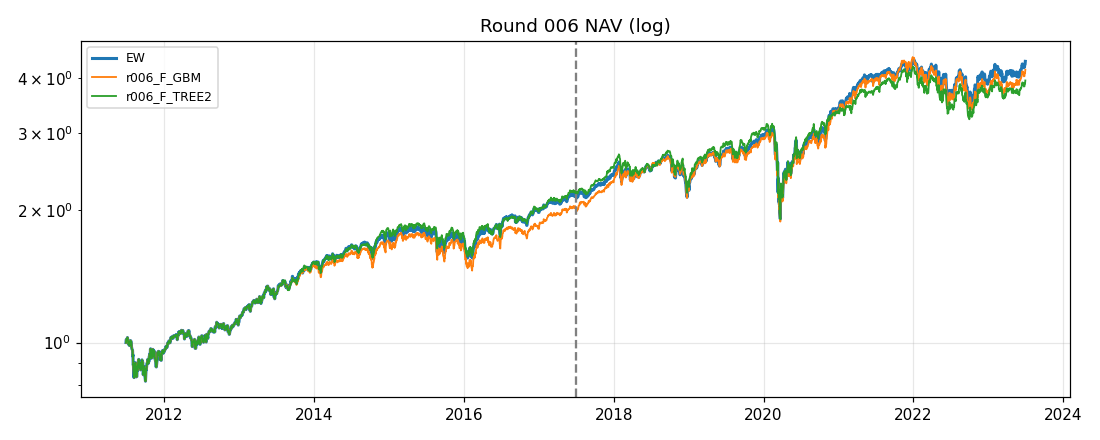

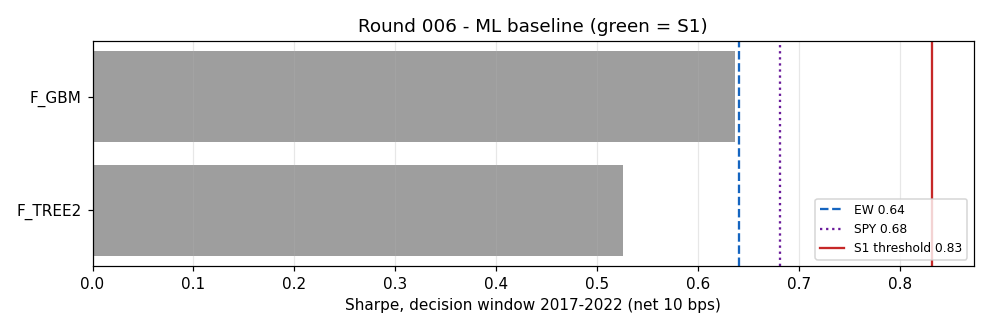

In [2]:
for f in sorted(pathlib.Path("../figures").glob("round_006_*.png")): display(Image(filename=str(f)))

In [3]:
display(Markdown(pathlib.Path("../rounds/round_006/RESULTS.md").read_text()))

# Round 006 — ผล (ตระกูล F: ML baseline) — **ไม่มีผู้เข้ารอบ**

- trial รอบนี้ 2 → สะสม **93**; ตาราง `results.csv`; กฎของ tree ทุกปี `tree_rules.txt`

| ผลสำคัญ | ตัวเลข |
|---|---|
| F_GBM (19 feature, walk-forward) | Sharpe ช่วงตัดสิน 0.636 ≈ EW 0.640 (SPY 0.681), S2 30%, DSR 0.013 |
| F_TREE2 (กฎจาก tree ลึก 2) | 0.526 — แพ้ EW |
| ความเสถียรของกฎ | tree 10 ปี มี feature ที่ใช้แบ่งชั้นแรก:    4 V_FCFP;   1 V_BM;   1 I_LOWISS;   1 I_LOWAG;   1 C_MOM;   1 C_LOWVOL;   1 A_SHY; → กฎเปลี่ยนเกือบทุกปี |

## การตีความ
- แม้ให้ ML ใช้ข้อมูลทุกตัวแบบ walk-forward ก็ยังได้แค่ระดับ EW → ข้อมูลพื้นฐาน + ราคาของหุ้นใหญ่ใน S&P 500 ช่วงนี้มีสัญญาณที่ใช้ได้จริงน้อยมาก
- กฎที่สกัดได้ไม่เสถียรข้ามปี (ตัวแปรหลักเปลี่ยนตลอด) → ไม่ใช่กฎที่ทนทาน
